# Segmentação de Clientes de uma Transportadora de Cargas Fracionadas
## Case Técnico Vaga Cientista de Dados - ESM | Fevreiro de 2026

---

Este notebook documenta o processo completo de análise da base de clientes de uma transportadora de cargas fracionadas, cobrindo três etapas principais:

1. **Análise Exploratória de Dados (EDA)**: Compreensão do negócio, perfil da base e comportamento operacional
2. **Ciclo 1 de Clusterização**: Primeira tentativa com KMeans, diagnóstico dos problemas encontrados
3. **Ciclo 2 de Clusterização**: Versão corrigida com engenharia de features, transformação logarítmica e recorte geográfico

O período analisado compreende os 26 dias úteis de janeiro de 2026. Os dados foram extraídos de um banco PostgreSQL no Rander contendo três tabelas:
- `fato_volumetria`, `dim_cliente` e `dim_cliente_cnae`.


---
# Parte 1:  Análise Exploratória de Dados


## 1.1 Configuração do Ambiente


In [63]:
import yaml
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sqlalchemy import create_engine, text
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

CORES = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

## 1.2 Carregamento dos Dados

A query consolida as três tabelas em uma visão única por registro de viagem, trazendo as dimensões operacionais (peso, volume, CTes) junto com o perfil do cliente (tipo, UF, CNAE principal).


In [38]:
# Mude para True para conectar ao banco e carregar os dados diretamente
conect_db = False  

In [44]:
if conect_db:
    
    # Carregar credenciais
    with open('./config/database_config.yaml', 'r') as f:
        config = yaml.safe_load(f)

    # String de conexão
    conn_string = f"postgresql://{config['user']}:{config['password']}@{config['host']}:{config['port']}/{config['database']}"

    try:
        # Testar conexão
        engine = create_engine(conn_string)
        with engine.connect() as conn:
            result = conn.execute(text("SELECT 1 as test"))
            print("conectado!")
            
            # Testar query simples
            result = conn.execute(text("SELECT version();"))
            version = result.fetchone()
            print(f"PostgreSQL: {version[0][:50]}...")
            
    except Exception as e:
        print(f"ERRO: {e}")

    # Query SQL unificando as tabelas (Master Query)
    query = """
            WITH cnae_principal AS (
                    SELECT 
                        cli_codigo,
                        cne_cnae_principal,
                        cnae,
                        cnae_descr
                    FROM 
                        dim_cliente_cnae
                    WHERE cne_cnae_principal = 1
            )
            SELECT 
                f.dt_viagem,
                f.via_codigo,
                f.cli_codigo,
                f.peso,
                f.m3,
                f.pesom3,
                f.perc_descm3,
                f.qtd_ctes,
                f.volumes,
                f.tipopesocubico,
                c.razao,
                c.cli_fisjur,
                c.uf_sigla,
                c.loc_descricao,
                cn.cne_cnae_principal,
                cn.cnae,
                cn.cnae_descr
            FROM fato_volumetria f
            LEFT JOIN dim_cliente c ON f.cli_codigo = c.cli_codigo 
            LEFT JOIN cnae_principal cn ON f.cli_codigo = cn.cli_codigo 
            """
    print("Carregando dados do banco...")
    df = pd.read_sql(query, engine)

    df.to_csv('./data/volumetria_unificada.csv', index=False)
    print("Dados carregados do banco e salvos no CSV unificado.")

else:    
    # Carrega o CSV unificado (caso já tenha carregado do banco ou não queira conectar)
    df = pd.read_csv('./data/volumetria_unificada.csv')
    df['dt_viagem'] = pd.to_datetime(df['dt_viagem'], errors='coerce')
    print("Dados carregados do CSV unificado.")




print(f'{df.shape[0]:,} registros carregados | {df["cli_codigo"].nunique():,} clientes unicos')

Dados carregados do CSV unificado.
1,093,129 registros carregados | 84,491 clientes unicos


## 1.3 Visão Geral da Base


In [46]:
# Periodo dos dados
print(f"\nPeríodo:")
print(f'  Inicio : {df["dt_viagem"].min().date()}')
print(f'  Fim    : {df["dt_viagem"].max().date()}')
print(f'  Dias   : {(df["dt_viagem"].max() - df["dt_viagem"].min()).days}')

# Total de viagens (via_codigo únicos)
print(f"\nTotal de viagens (via_codigo únicos): {df['via_codigo'].nunique():,}")

# Total de conhecimentos (CTes)
print(f"\nTotal de conhecimentos (CTes): {df['qtd_ctes'].sum():,}")

# Total de Clientes únicos
print(f"\nClientes únicos ativos: {df['cli_codigo'].nunique():,}")

# Peso total transportado
print(f"\nPeso total transportado (kg): {df['pesom3'].sum():,.0f}")

# Volume total transportado
print(f"\nVolume total (m³): {df['m3'].sum():,.2f}")

# Valores nulos por coluna
print(f"\nValores nulos por coluna:\n{df.isnull().sum()}")


Período:
  Inicio : 2026-01-01
  Fim    : 2026-01-26
  Dias   : 25

Total de viagens (via_codigo únicos): 18,289

Total de conhecimentos (CTes): 1,499,313

Clientes únicos ativos: 84,491

Peso total transportado (kg): 77,700,598

Volume total (m³): 159,673.97

Valores nulos por coluna:
dt_viagem             58820
via_codigo                0
cli_codigo                0
peso                      0
m3                        0
pesom3                    0
perc_descm3               0
qtd_ctes                  0
volumes                   0
tipopesocubico            0
razao                     0
cli_fisjur                0
uf_sigla                  0
loc_descricao             0
cne_cnae_principal    19061
cnae                  19061
cnae_descr            19061
dtype: int64


### Observações iniciais

- O campo `cnae_descr` apresenta valores nulos para clientes sem CNAE cadastrado, isso será tratado nas análises de perfil.
- Todas as colunas operacionais (peso, volume, CTes) estão sem nulos, o que indica boa qualidade na carga dos dados.


## 1.4 Análise Temporal

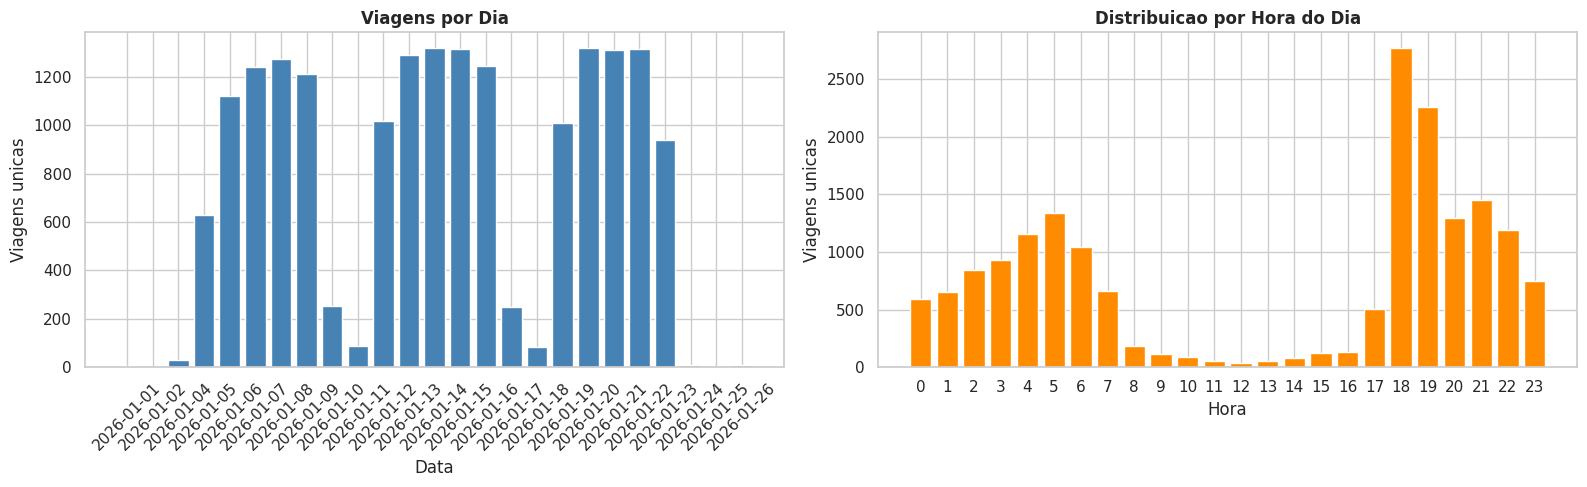

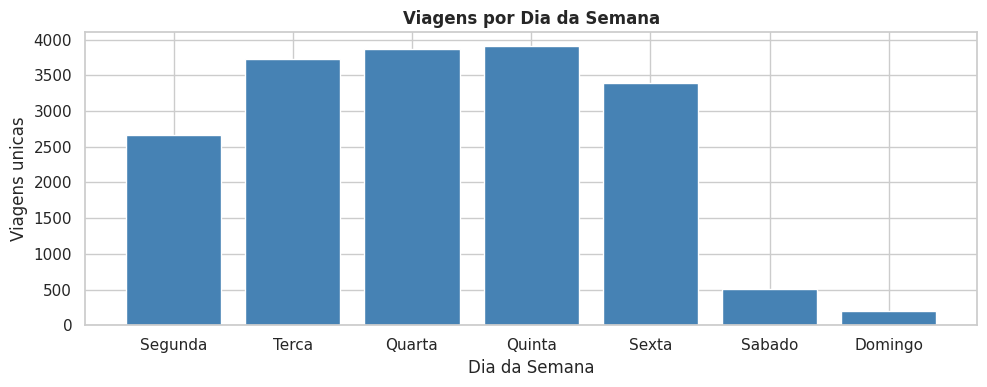

In [47]:
df['dia']        = df['dt_viagem'].dt.date
df['dia_semana'] = df['dt_viagem'].dt.day_name()
df['hora']       = df['dt_viagem'].dt.hour

viagens_dia = df.groupby('dia')['via_codigo'].nunique().reset_index()
viagens_dia.columns = ['dia', 'qtd_viagens']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(viagens_dia['dia'].astype(str), viagens_dia['qtd_viagens'], color='steelblue')
axes[0].set_title('Viagens por Dia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Data')
axes[0].set_ylabel('Viagens unicas')
axes[0].tick_params(axis='x', rotation=45)

ordem_horas = list(range(24))
viagens_hora = df.groupby('hora')['via_codigo'].nunique().reindex(ordem_horas, fill_value=0)
axes[1].bar(viagens_hora.index, viagens_hora.values, color='darkorange')
axes[1].set_title('Distribuicao por Hora do Dia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Viagens unicas')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

ordem_semana = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_semana = ['Segunda','Terca','Quarta','Quinta','Sexta','Sabado','Domingo']
viagens_semana = df.groupby('dia_semana')['via_codigo'].nunique().reindex(ordem_semana).fillna(0)

plt.figure(figsize=(10, 4))
plt.bar(labels_semana, viagens_semana.values, color='steelblue')
plt.title('Viagens por Dia da Semana', fontsize=12, fontweight='bold')
plt.xlabel('Dia da Semana')
plt.ylabel('Viagens unicas')
plt.tight_layout()
plt.show()

### Leitura

A operacao é fortemente concentrada nos dias úteis, com queda acentuada no final de semana. O padrão intradiário revela dois picos de saída de carga: um no início da manhã e outro no final do dia, típico de transportadoras com coletas programadas.


## 1.5 Perfil dos Clientes


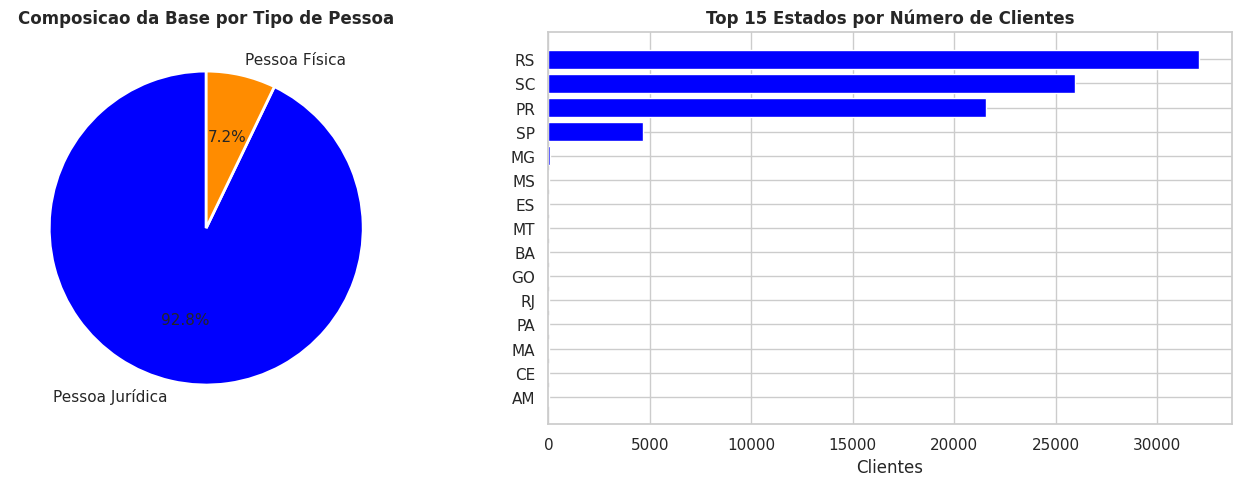

In [53]:
perfil = df.drop_duplicates('cli_codigo')[['cli_codigo', 'cli_fisjur']].copy()
pf_pj  = (
    perfil['cli_fisjur']
    .map({'F': 'Pessoa Física', 'J': 'Pessoa Jurídica'})
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    pf_pj.values, labels=pf_pj.index, autopct='%1.1f%%',
    colors=['blue', 'darkorange'], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Composicao da Base por Tipo de Pessoa', fontsize=12, fontweight='bold')

top_uf = (
    df.drop_duplicates('cli_codigo')
    .groupby('uf_sigla')['cli_codigo']
    .count()
    .sort_values(ascending=False)
    .head(15)
)
axes[1].barh(top_uf.index[::-1], top_uf.values[::-1], color='blue')
axes[1].set_title('Top 15 Estados por Número de Clientes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clientes')

plt.tight_layout()
plt.show()

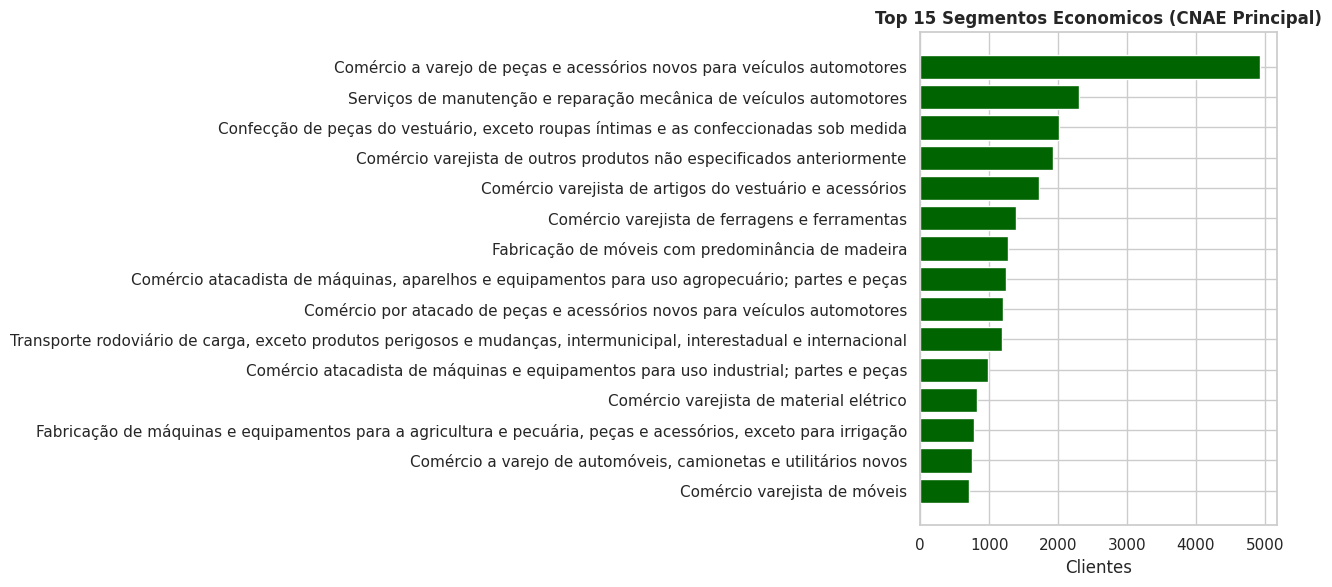

In [52]:
cnae_clientes = df.dropna(subset=['cnae_descr']).drop_duplicates('cli_codigo')
top_cnae      = cnae_clientes['cnae_descr'].value_counts().head(15)

plt.figure(figsize=(13, 6))
plt.barh(top_cnae.index[::-1], top_cnae.values[::-1], color='darkgreen')
plt.title('Top 15 Segmentos Economicos (CNAE Principal)', fontsize=12, fontweight='bold')
plt.xlabel('Clientes')
plt.tight_layout()
plt.show()

## 1.6 Distribuicao das Metricas Operacionais


,pesom3,peso,m3,qtd_ctes,volumes,perc_descm3
count,1093129.00,1093129.00,1093129.00,1093129.00,1093129.00,1093129.00
mean,71.08,85.11,0.15,1.37,6.45,0.84
std,263.58,276.61,3.07,1.86,24.80,6.68
min,0.00,0.00,0.00,1.00,1.00,0.00
25%,2.00,4.10,0.00,1.00,1.00,0.00
50%,10.00,16.22,0.00,1.00,2.00,0.00
75%,42.38,60.00,0.00,1.00,4.00,0.00
max,16495.38,16495.38,3030.63,154.00,4575.00,1485.00


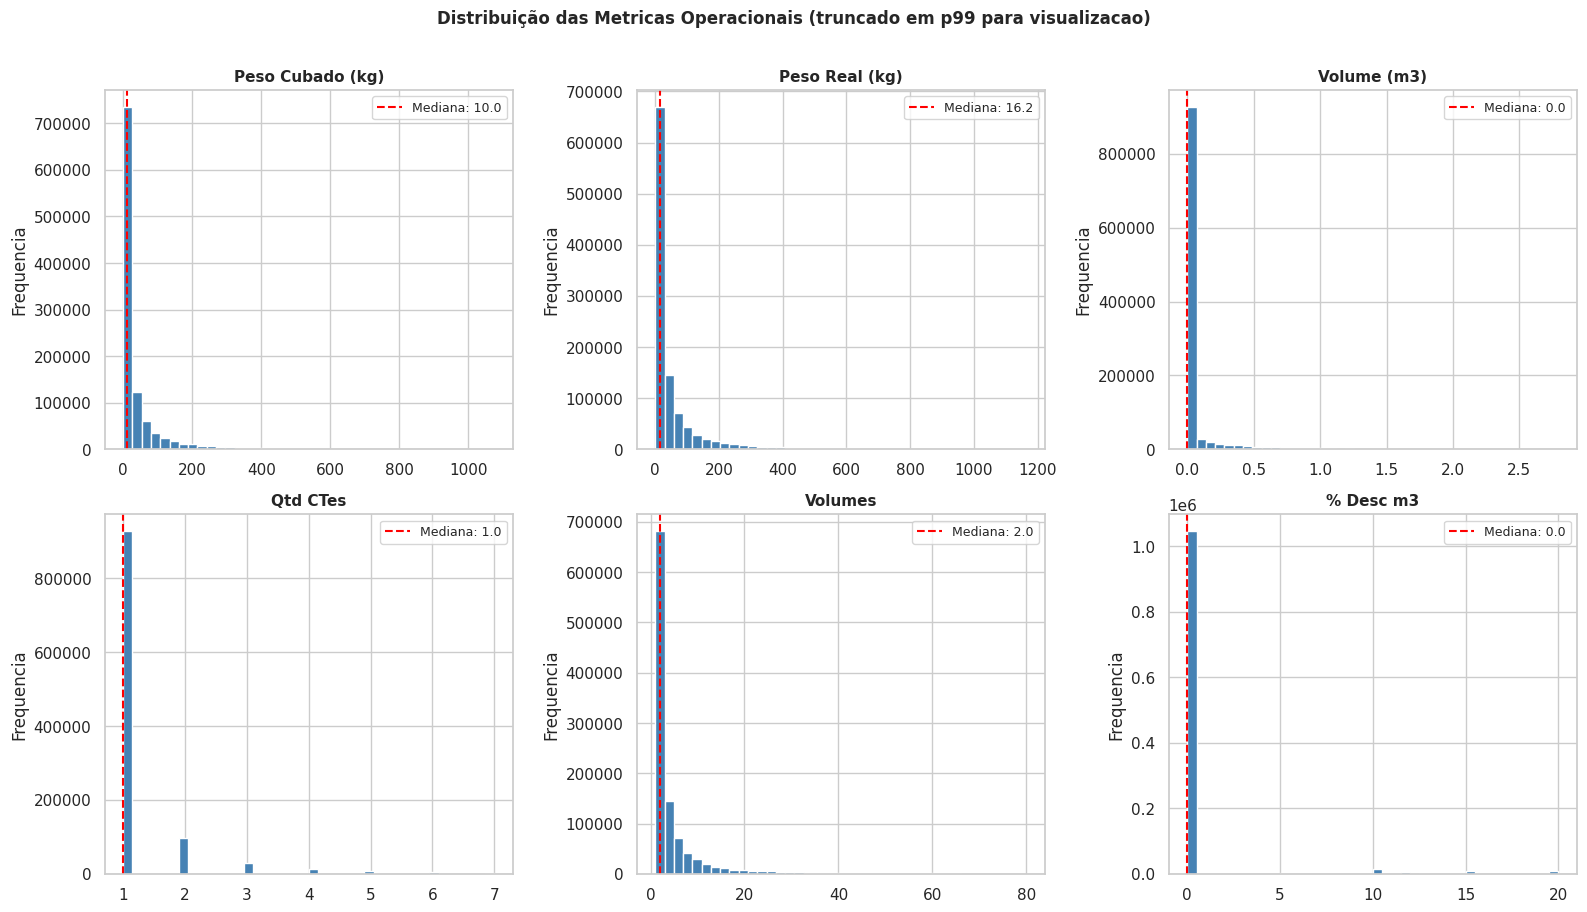

In [ ]:
cols_op  = ['pesom3', 'peso', 'm3', 'qtd_ctes', 'volumes', 'perc_descm3']
titulos  = ['Peso Cubado (kg)', 'Peso Real (kg)', 'Volume (m3)', 'Qtd CTes', 'Volumes', '% Desc m3']

display(df[cols_op].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, titulo) in enumerate(zip(cols_op, titulos)):
    dados = df[col].dropna()
    limite = dados.quantile(0.99)
    dados_plot = dados[dados <= limite]
    axes[i].hist(dados_plot, bins=40, color='steelblue', edgecolor='white')
    axes[i].axvline(dados.median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {dados.median():.1f}')
    axes[i].set_title(titulo, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequencia')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das Metricas Operacionais (truncado em p99 para visualização)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

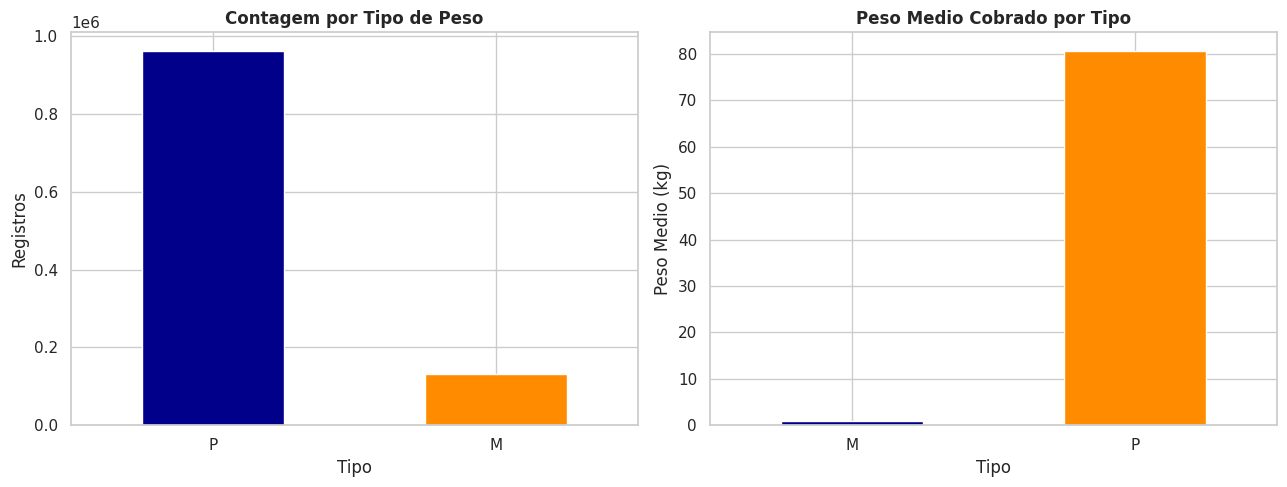


Nota: o tipo define qual peso e usado para calculo do frete.
Tipo M indica carga leve e volumosa (ex: embalagens, textil).
Tipo P indica carga densa (ex: metalurgia, alimentos industriais).

Distribuição do campo tipopesocubico:
  M (peso cubado > peso real) : 12.0%
  P (peso real > peso cubado) : 88.0%


In [57]:
tipo_counts = df['tipopesocubico'].value_counts()
tipo_pct    = tipo_counts / tipo_counts.sum() * 100


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tipo_counts.plot(kind='bar', ax=axes[0], color=['darkblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Contagem por Tipo de Peso', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Registros')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('tipopesocubico')['pesom3'].mean().plot(
    kind='bar', ax=axes[1], color=['darkblue', 'darkorange'], edgecolor='white'
)
axes[1].set_title('Peso Medio Cobrado por Tipo', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Peso Medio (kg)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print()
print('Nota: o tipo define qual peso e usado para calculo do frete.')
print('Tipo M indica carga leve e volumosa (ex: embalagens, textil).')
print('Tipo P indica carga densa (ex: metalurgia, alimentos industriais).')
print()
print('Distribuição do campo tipopesocubico:')
print(f'  M (peso cubado > peso real) : {tipo_pct.get("M", 0):.1f}%')
print(f'  P (peso real > peso cubado) : {tipo_pct.get("P", 0):.1f}%')

### Leitura

88% dos registros sao do tipo P, ou seja, o peso real supera o peso cubado na grande maioria das operacoes. Isso indica que a frota carrega principalmente mercadorias densas. O tipo M, apesar de minoritario, exige atencao especial no calculo do frete, pois o preco e determinado pelo volume e nao pelo peso.


## 1.7 Concentração por Cliente


In [13]:
df_cli_agg = df.groupby('cli_codigo').agg(
    total_viagens    = ('via_codigo',     'nunique'),
    total_ctes       = ('qtd_ctes',       'sum'),
    total_volumes    = ('volumes',        'sum'),
    total_peso       = ('pesom3',         'sum'),
    total_m3         = ('m3',             'sum'),
    media_perc_desc  = ('perc_descm3',    'mean'),
).reset_index()

df_info_cli = df.drop_duplicates('cli_codigo')[['cli_codigo', 'cli_fisjur', 'uf_sigla', 'cnae_descr']]
df_cli_agg  = df_cli_agg.merge(df_info_cli, on='cli_codigo', how='left')

print(f'Base agregada: {df_cli_agg.shape[0]:,} clientes')
display(df_cli_agg.describe().round(2))

Base agregada: 84,491 clientes


,cli_codigo,total_viagens,total_ctes,total_volumes,total_peso,total_m3,media_perc_desc
count,84491.00,84491.00,84491.00,84491.00,84491.00,84491.00,84491.00
mean,3454289.68,12.11,17.75,83.50,919.63,1.89,0.22
std,842445.18,38.53,104.36,947.15,7805.54,24.80,1.56
min,2646.00,1.00,1.00,1.00,0.00,0.00,0.00
25%,2925899.50,2.00,2.00,3.00,12.00,0.00,0.00
50%,3523293.00,3.00,4.00,6.00,57.44,0.00,0.00
75%,4091122.50,8.00,8.00,22.00,251.60,0.17,0.00
max,4927906.00,1703.00,12358.00,110008.00,574491.25,3030.63,50.00


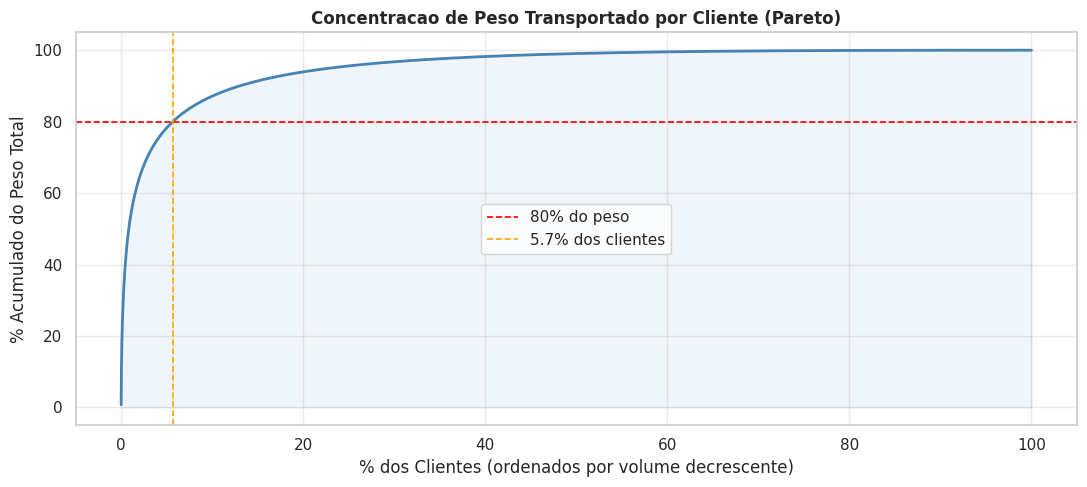

5.7% dos clientes concentram 80% do peso total transportado.


In [58]:
df_pareto = df_cli_agg.sort_values('total_peso', ascending=False).reset_index(drop=True)
df_pareto['perc_acum']     = df_pareto['total_peso'].cumsum() / df_pareto['total_peso'].sum() * 100
df_pareto['perc_clientes'] = (df_pareto.index + 1) / len(df_pareto) * 100

ponto_80 = df_pareto[df_pareto['perc_acum'] >= 80].iloc[0]

plt.figure(figsize=(11, 5))
plt.plot(df_pareto['perc_clientes'], df_pareto['perc_acum'], color='steelblue', linewidth=2)
plt.axhline(80, color='red',    linestyle='--', linewidth=1.2, label='80% do peso')
plt.axvline(ponto_80['perc_clientes'], color='orange', linestyle='--', linewidth=1.2,
            label=f'{ponto_80["perc_clientes"]:.1f}% dos clientes')
plt.fill_between(df_pareto['perc_clientes'], df_pareto['perc_acum'], alpha=0.08, color='steelblue')
plt.title('Concentracao de Peso Transportado por Cliente (Pareto)', fontsize=12, fontweight='bold')
plt.xlabel('% dos Clientes (ordenados por volume decrescente)')
plt.ylabel('% Acumulado do Peso Total')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f'{ponto_80["perc_clientes"]:.1f}% dos clientes concentram 80% do peso total transportado.')

### Leitura

A curva de Pareto confirma concentração extrema: aproximadamente 5,7% dos clientes respondem por 80% do peso total. Essa estrutura e característica do mercado B2B de carga fracionada, onde indústrias e atacadistas representam o grosso do volume enquanto a base de pequenos clientes e pulverizada.

Esse achado tem implicação direta na segmentação: é necessário distinguir clientes pelo seu padrao de uso, nao apenas pelo volume absoluto.


## 1.8 Correlacoes entre Variaveis


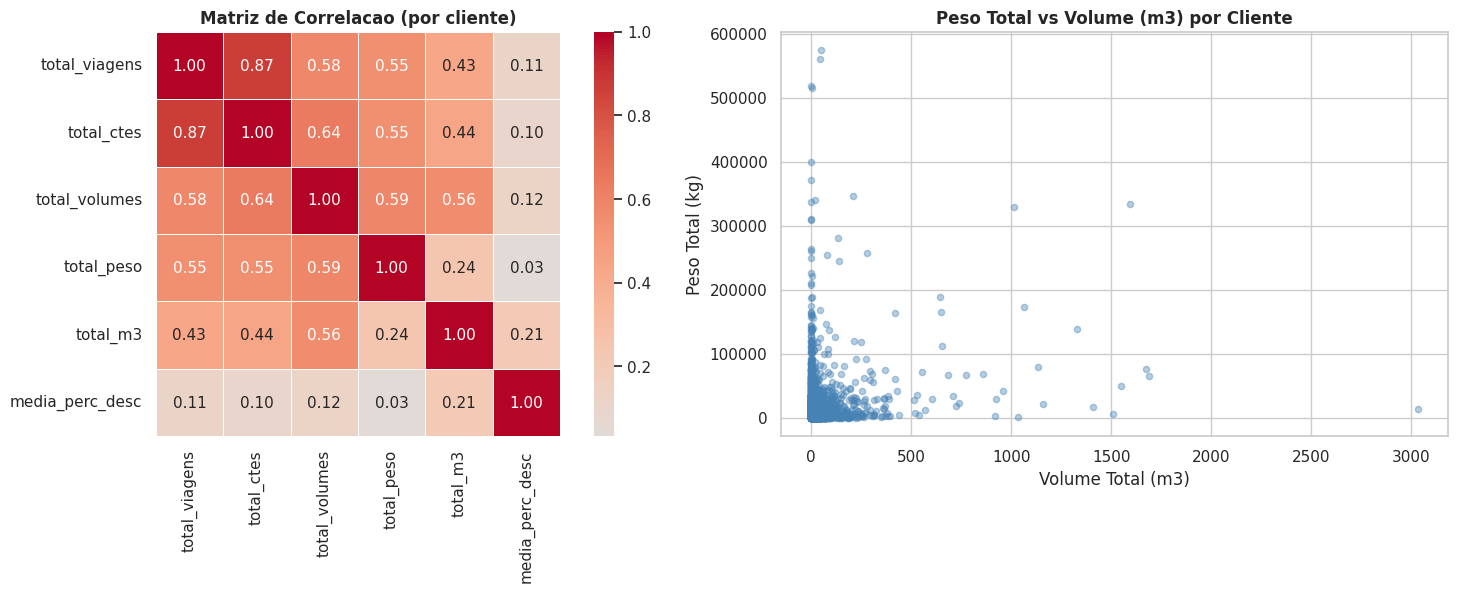

In [ ]:
cols_corr = ['total_viagens', 'total_ctes', 'total_volumes', 'total_peso', 'total_m3', 'media_perc_desc']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = df_cli_agg[cols_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Matriz de Correlação (por cliente)', fontsize=12, fontweight='bold')

axes[1].scatter(df_cli_agg['total_m3'], df_cli_agg['total_peso'],
                alpha=0.4, color='steelblue', s=20)
axes[1].set_title('Peso Total vs Volume (m3) por Cliente', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volume Total (m3)')
axes[1].set_ylabel('Peso Total (kg)')

plt.tight_layout()
plt.show()

### Leitura

Peso, volume e CTes sao altamente correlacionados entre si, o que era esperado. O percentual de desconto apresenta correlação próxima de zero com as demais variáveis, sugerindo que a política de desconto nao é diretamente proporcional ao volume, pode haver negociações individuais ou faixas de preços definidas por contrato.

A correlação linear entre peso e m3 não é perfeita, refletindo a heterogeneidade entre tipos de carga (densas vs volumosas).


## 1.9 Sintese da EDA:  Hipoteses para a Segmentacao

Com base nas analises acima, algumas hipoteses guiam a etapa de clusterização:

**H1:  Concentração na cauda longa**
- Poucos clientes (estimativa: <10%) concentram a maior parte do peso transportado. Qualquer segmentação baseada apenas em totais absolutos irá separar esses "gigantes" do restante da base, sem produzir grupos úteis para acao comercial.

**H2: Sazonalidade semanal clara**
- A operacao é concentrada em dias úteis. Clientes que enviam apenas em determinados dias da semana podem representar perfis distintos (ex: industrias com producao semanal vs comércio com demanda diária).

**H3: Cubagem como proxy do tipo de mercadoria**
- A proporcao de cargas do tipo M vs P por cliente pode funcionar como indicador do setor econômico, complementando o CNAE.

**H4: Existencia de grupos comportamentais distintos**
- A variabilidade observada nas métricas operacionais (CTes, frequencia, peso por nota) sugere que a base possui subgrupos com padrões de uso diferentes, que não são capturados por segmentações simples por UF ou CNAE.


---
# Parte 2: Ciclo 1 de Clusterizacao: Abordagem Inicial

Neste primeiro ciclo, a segmentação foi aplicada diretamente sobre os totais agregados por cliente, com normalização padrão via `StandardScaler`. O objetivo desta seção é documentar os problemas encontrados e justificar as decisões de melhoria adotadas no Ciclo 2.


## 2.1 Preparação das Features 


Features utilizadas: totais absolutos de viagens, CTes, volumes, peso, m3 e percentual medio de desconto. Normalização via `StandardScaler`.


In [60]:
features_v1 = [
    'total_viagens',
    'total_ctes',
    'total_volumes',
    'total_peso',
    'total_m3',
    'media_perc_desc',
]

df_kmeans_v1 = df_cli_agg[['cli_codigo'] + features_v1].dropna().copy()
X_v1         = df_kmeans_v1[features_v1].values

scaler_v1 = StandardScaler()
X_v1_sc   = scaler_v1.fit_transform(X_v1)

print(f'Base para clusterização: {X_v1_sc.shape[0]:,} clientes | {X_v1_sc.shape[1]} features')

Base para clusterização: 84,491 clientes | 6 features


## 2.2 Selecao do Número de Clusters 


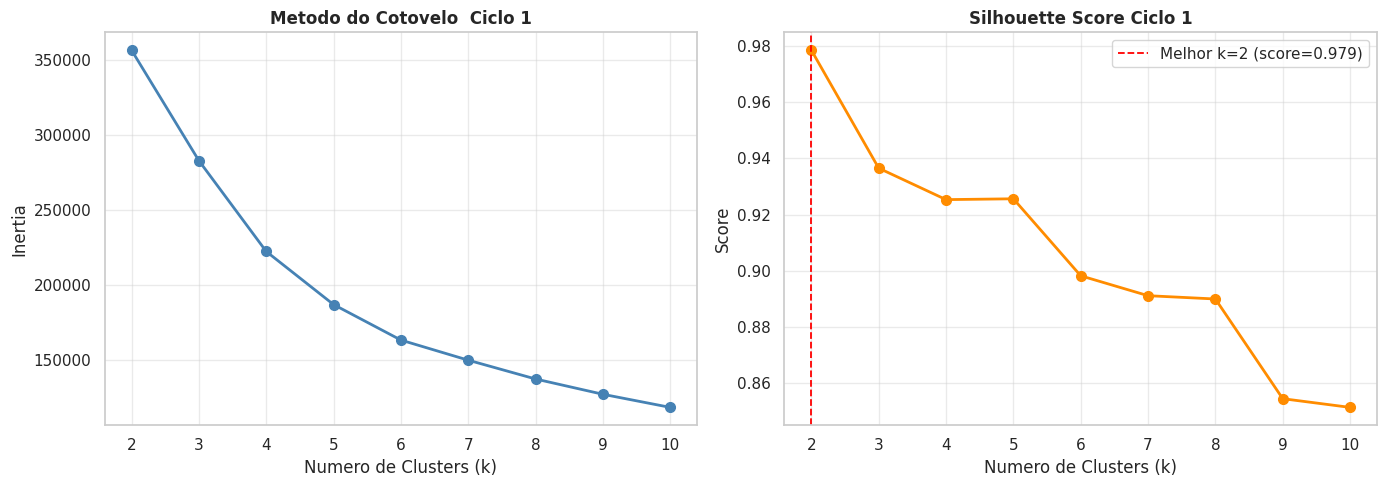

Silhouette máximo: 0.979 com k=2


In [61]:
k_range     = range(2, 11)
inertias_v1 = []
silhs_v1    = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_v1_sc)
    inertias_v1.append(km.inertia_)
    silhs_v1.append(silhouette_score(X_v1_sc, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias_v1, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_title('Metodo do Cotovelo  Ciclo 1', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero de Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.4)

axes[1].plot(list(k_range), silhs_v1, 'o-', color='darkorange', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score Ciclo 1', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.4)

best_k_v1 = list(k_range)[silhs_v1.index(max(silhs_v1))]
axes[1].axvline(best_k_v1, color='red', linestyle='--', linewidth=1.3,
                label=f'Melhor k={best_k_v1} (score={max(silhs_v1):.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Silhouette máximo: {max(silhs_v1):.3f} com k={best_k_v1}')

### Diagnóstico do Resultado

O Silhouette Score de **0.979 com k=2** parece excelente a primeira vista, mas é um sinal de alerta. Um score tão próximo de 1 em dados de negócio quase sempre indica que o algoritmo encontrou um ou poucos outliers extremos separados de toda a base e não grupos comportamentais reais.


## 2.3 Aplicação do Modelo


In [67]:
K_V1 = 2

km_v1 = KMeans(n_clusters=K_V1, random_state=42, n_init=10)
df_kmeans_v1['cluster'] = km_v1.fit_predict(X_v1_sc)

print(f'Distribuição dos clusters com k={K_V1}:')
dist_v1 = df_kmeans_v1['cluster'].value_counts().sort_index()
for k, n in dist_v1.items():
    print(f'  Cluster {k}: {n:>6,} clientes ({n / len(df_kmeans_v1) * 100:.1f}%)')

Distribuição dos clusters com k=2:
  Cluster 0: 84,361 clientes (99.8%)
  Cluster 1:    130 clientes (0.2%)


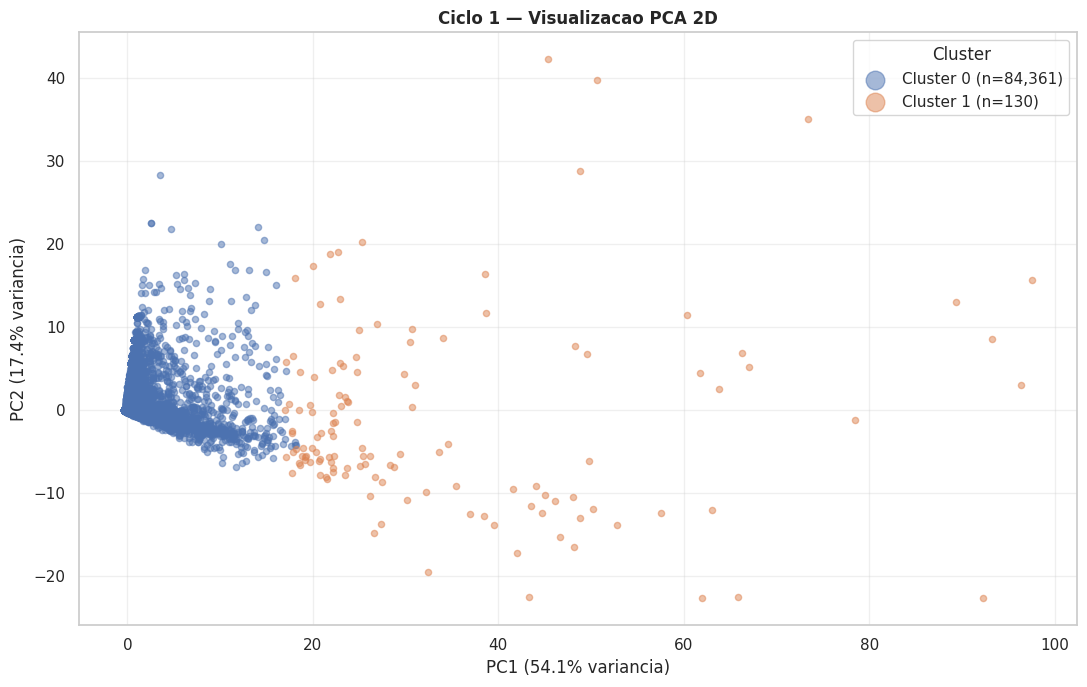

In [68]:
pca_v1  = PCA(n_components=2, random_state=42)
X_pca_v1 = pca_v1.fit_transform(X_v1_sc)

plt.figure(figsize=(11, 7))
for i in range(K_V1):
    mask = df_kmeans_v1['cluster'] == i
    plt.scatter(
        X_pca_v1[mask, 0], X_pca_v1[mask, 1],
        label=f'Cluster {i} (n={mask.sum():,})',
        alpha=0.5, s=20, color=CORES[i % len(CORES)]
    )
plt.title('Ciclo 1 — Visualizacao PCA 2D', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({pca_v1.explained_variance_ratio_[0]*100:.1f}% variancia)')
plt.ylabel(f'PC2 ({pca_v1.explained_variance_ratio_[1]*100:.1f}% variancia)')
plt.legend(title='Cluster', markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.4 Diagnostico dos Problemas: Por que o Ciclo 1 Falhou

O resultado com k=2 revelou o seguinte:

| Cluster | Clientes | % da Base |
|---------|----------|-----------|
| 0 | 82.573 | 99,8% |
| 1 | 130 | 0,2% |


Quase toda a base ficou agrupada no cluster 0, o que nao tem utilidade pratica. Dois problemas estruturais causaram isso:

**Problema 1: Distribuicao extremamente assimetrica (skewed)**

- Os dados possuem forte concentracao na cauda esquerda: a mediana de `total_viagens` e 3, mas o maximo e 1.703. O `StandardScaler` centraliza e escala os dados, mas nao corrige a assimetria, outliers continuam dominando o espaco vetorial. No contexto do KMeans, que minimiza distancias euclidianas, isso faz com que os centroides sejam puxados em direcao aos valores extremos.

**Problema 2: Features apenas de volume absoluto**

- Usar apenas totais (peso total, CTes total, viagens totais) faz com que a clusterizacao separe clientes pelo tamanho, nao pelo comportamento. Dois clientes com volume similar podem ter perfis operacionais completamente diferentes: um com muitas viagens pequenas e frequentes, outro com poucas viagens mas cargas pesadas e esporadicas.

Essas questões leva para mais uma rodada de Ciclo.


---
# Parte 3: Ciclo 2 de Clusterização: 
As correções aplicadas neste ciclo endereçam diretamente os problemas identificados no Ciclo 1:

- **Recorte geografico**: restrição aos estados com maior densidade operacional, garantindo que os clientes analisados compartilham o mesmo contexto logístico
- **Engenharia de features comportamentais**: criação de ratios e métricas por viagem que capturam *como* o cliente usa a transportadora, independente do seu tamanho absoluto
- **Transformacao logaritmica**: aplicada antes da normalização para comprimir a cauda das distribuições e reduzir a dominancia dos outliers
- **Tratamento de outliers extremos**: separados antes do fit e reclassificados ao final, preservando a qualidade dos centroides
- **Tres metricas de avaliacao**: Elbow, Silhouette e Davies-Bouldin para uma escolha mais robusta de k


## 3.1 Recorte Geográfico: Seleção dos Estados de Maior Densidade Operacional

Em transporte de cargas fracionadas, o numero de viagens por estado e um proxy direto da cobertura de agências e da densidade operacional da transportadora. Comparar clientes de estados com malhas muito diferentes introduziria ruido na segmentação: um cliente "ativo" em um estado com poucas rotas tem comportamento incomparavel com um cliente equivalente em um estado com alta cobertura.


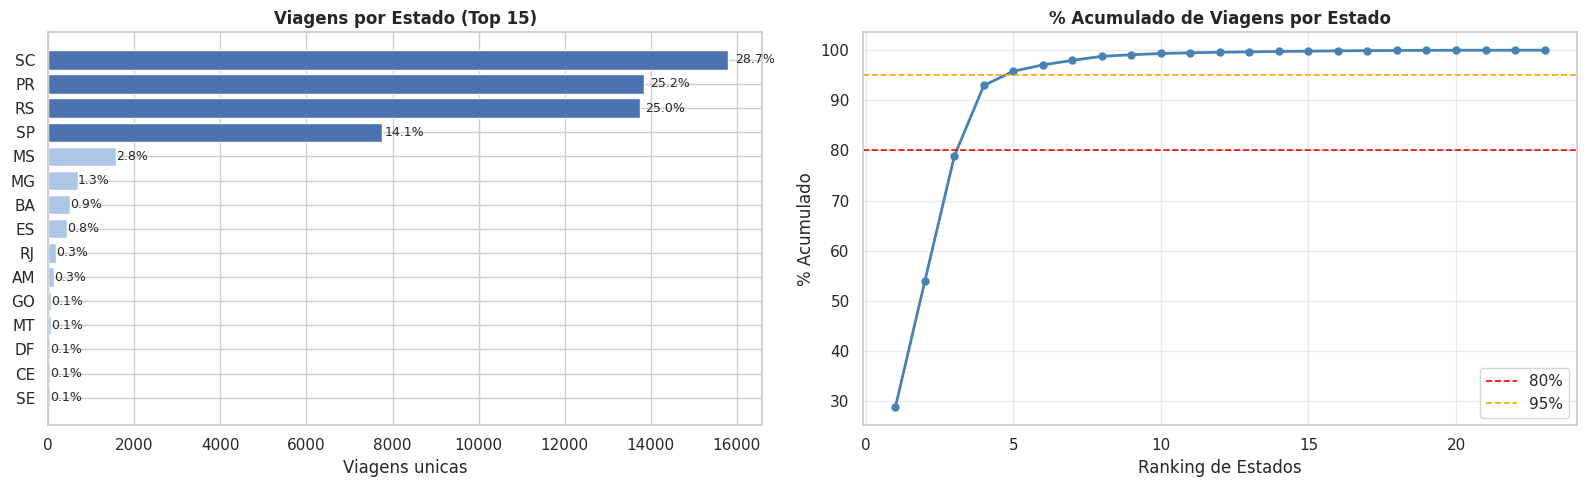

Top 10 estados:
uf_sigla  qtd_viagens       pct  pct_acum
      SC        15801 28.724913 28.724913
      PR        13853 25.183610 53.908522
      RS        13738 24.974549 78.883072
      SP         7745 14.079770 92.962842
      MS         1564  2.843223 95.806065
      MG          689  1.252545 97.058610
      BA          507  0.921684 97.980294
      ES          436  0.792612 98.772906
      RJ          175  0.318136 99.091041
      AM          139  0.252691 99.343732


In [22]:
viagens_por_uf = (
    df.groupby('uf_sigla')['via_codigo']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)
viagens_por_uf.columns = ['uf_sigla', 'qtd_viagens']
viagens_por_uf['pct']      = viagens_por_uf['qtd_viagens'] / viagens_por_uf['qtd_viagens'].sum() * 100
viagens_por_uf['pct_acum'] = viagens_por_uf['pct'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top15     = viagens_por_uf.head(15)
cores_bar = ['#4C72B0' if i < 4 else '#aec6e8' for i in range(len(top15))]
axes[0].barh(top15['uf_sigla'][::-1], top15['qtd_viagens'][::-1], color=cores_bar[::-1])
axes[0].set_title('Viagens por Estado (Top 15)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Viagens unicas')

for i, (_, row) in enumerate(top15.iloc[::-1].iterrows()):
    axes[0].text(row['qtd_viagens'] * 1.01, i, f'{row["pct"]:.1f}%', va='center', fontsize=9)

axes[1].plot(range(1, len(viagens_por_uf) + 1), viagens_por_uf['pct_acum'],
             'o-', color='steelblue', lw=2, ms=5)
axes[1].axhline(80, color='red',    ls='--', lw=1.2, label='80%')
axes[1].axhline(95, color='orange', ls='--', lw=1.2, label='95%')
axes[1].set_title('% Acumulado de Viagens por Estado', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ranking de Estados')
axes[1].set_ylabel('% Acumulado')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('Top 10 estados:')
print(viagens_por_uf.head(10).to_string(index=False))

In [69]:
# SC, PR, RS e SP concentram ~93% das viagens criterio de corte natural
N_TOP = 4
top_estados = viagens_por_uf.head(N_TOP)['uf_sigla'].tolist()

df = df[df['uf_sigla'].isin(top_estados)].copy()

n_cli = df['cli_codigo'].nunique()
n_via = df['via_codigo'].nunique()

print(f'Estados selecionados : {top_estados}')
print(f'Clientes unicos      : {n_cli:,}')
print(f'Viagens unicas       : {n_via:,}')
print(f'Registros totais     : {len(df):,}')

Estados selecionados : ['SC', 'PR', 'RS', 'SP']
Clientes unicos      : 84,246
Viagens unicas       : 18,281
Registros totais     : 1,088,403


### Justificativa do corte

SC, PR, RS e SP concentram aproximadamente 93% das viagens totais. O quinto estado ja representa menos de 3%,  incluí-lo não acrescentaria representatividade suficiente para justificar a heterogeneidade introduzida.

Clientes dos demais estados nao são descartados da base de clientes da empresa, apenas ficam fora desta análise de segmentação, que e restrita aos mercados onde a transportadora tem presenca operacional relevante.


## 3.2 Engenharia de Features Comportamentais

A estrategia é criar variaveis que capturem o *padrão de uso* do cliente, e nao apenas o volume absoluto. Isso permite distinguir, por exemplo, um cliente que faz 10 viagens com 1 CTe cada (alta fragmentação) de outro que faz 10 viagens com 50 CTes cada (cliente consolidador).


In [70]:
df_agg = df.groupby('cli_codigo').agg(
    total_viagens   = ('via_codigo',     'nunique'),
    total_ctes      = ('qtd_ctes',       'sum'),
    total_volumes   = ('volumes',        'sum'),
    total_peso      = ('pesom3',         'sum'),
    total_m3        = ('m3',             'sum'),
    media_perc_desc = ('perc_descm3',    'mean'),
    std_peso        = ('pesom3',         'std'),
    tipo_M_pct      = ('tipopesocubico', lambda x: (x == 'M').mean() * 100),
    primeiro_envio  = ('dt_viagem',      'min'),
    ultimo_envio    = ('dt_viagem',      'max'),
).reset_index()

data_corte = df['dt_viagem'].max()

# CTes por viagem: indica se o cliente consolida muitas notas em cada visita
df_agg['ctes_por_viagem']   = df_agg['total_ctes'] / df_agg['total_viagens']

# Peso medio por CTe: proxy do tamanho medio de cada envio
df_agg['peso_por_cte']      = df_agg['total_peso'] / df_agg['total_ctes'].replace(0, np.nan)

# Volumes por CTe: proxy da fragmentacao fisica dos envios
df_agg['volumes_por_cte']   = df_agg['total_volumes'] / df_agg['total_ctes'].replace(0, np.nan)

# Recencia: dias desde o ultimo envio ate o fim do periodo analisado
df_agg['dias_desde_ultimo'] = (data_corte - df_agg['ultimo_envio']).dt.days

# Spread: janela temporal de atividade do cliente no periodo
df_agg['spread_dias']       = (df_agg['ultimo_envio'] - df_agg['primeiro_envio']).dt.days

# Frequencia diaria: viagens por dia de spread (normaliza pelo periodo de atividade)
df_agg['freq_diaria']       = df_agg['total_viagens'] / (df_agg['spread_dias'] + 1)

df_agg['std_peso']        = df_agg['std_peso'].fillna(0)
df_agg['peso_por_cte']    = df_agg['peso_por_cte'].fillna(0)
df_agg['volumes_por_cte'] = df_agg['volumes_por_cte'].fillna(0)

print(f'Feature engineering concluido: {df_agg.shape[0]:,} clientes | {df_agg.shape[1]} variaveis')

novas = ['ctes_por_viagem', 'peso_por_cte', 'volumes_por_cte',
         'dias_desde_ultimo', 'spread_dias', 'freq_diaria', 'tipo_M_pct']
display(df_agg[novas].describe().round(3))

Feature engineering concluido: 84,246 clientes | 17 variaveis


,ctes_por_viagem,peso_por_cte,volumes_por_cte,dias_desde_ultimo,spread_dias,freq_diaria,tipo_M_pct
count,84246.000,84246.000,84246.000,82392.000,82392.000,82392.000,84246.000
mean,1.101,43.259,3.119,7.394,5.704,1.699,8.554
std,0.304,118.807,7.898,5.417,6.659,2.098,23.783
min,1.000,0.001,1.000,0.000,0.000,0.105,0.000
25%,1.000,4.000,1.000,3.000,0.000,0.786,0.000
50%,1.000,12.852,1.333,5.000,2.000,1.500,0.000
75%,1.000,36.985,2.842,11.000,13.000,2.000,0.000
max,12.889,5472.090,946.000,24.000,24.000,275.000,100.000


## 3.3 Transformação Logaritmica e Normalização

O `log1p(x) = log(1 + x)` e aplicado nas features de escala continua antes do `StandardScaler`. A funcao é valida para x=0 e e inversivel via `expm1`. O efeito é comprimir a cauda direita das distribuições, fazendo o KMeans trabalhar sobre ordens de grandeza em vez de valores absolutos.

Features de percentual (`tipo_M_pct`, `media_perc_desc`) já são naturalmente limitadas e não precisam de transformacao logaritmica.


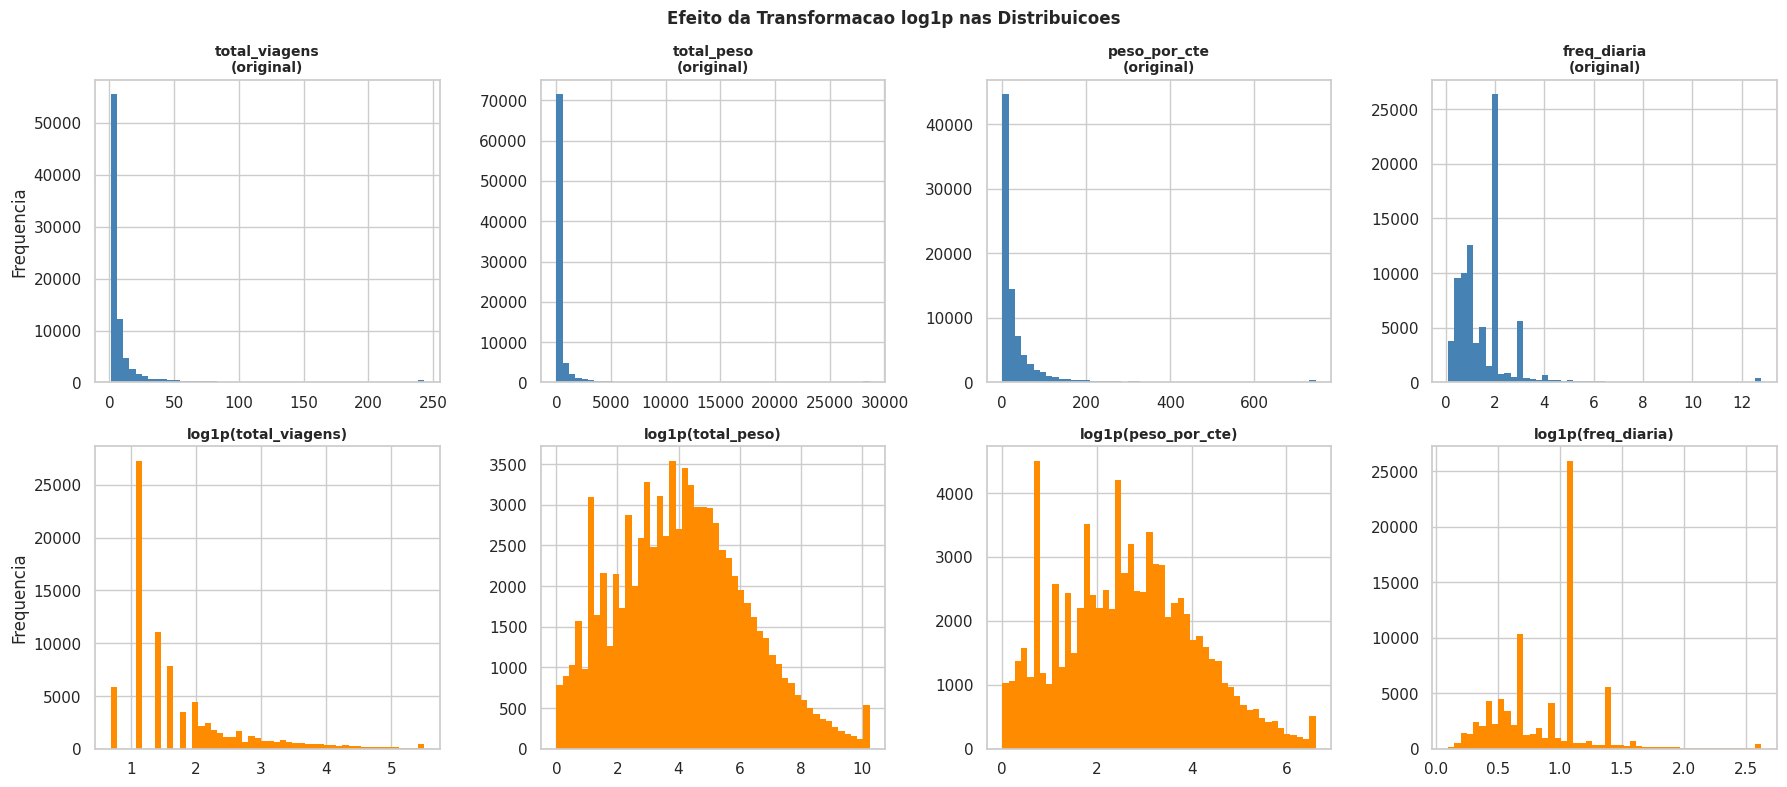

In [ ]:
FEATURES = [
    'total_viagens',      # volume operacional absoluto
    'total_peso',         # tamanho absoluto do cliente
    'ctes_por_viagem',    # padrao de consolidação de cargas
    'peso_por_cte',       # tamanho medio dos envios
    'volumes_por_cte',    # fragmentacao fisica
    'tipo_M_pct',         # perfil do tipo de mercadoria
    'dias_desde_ultimo',  # recencia
    'freq_diaria',        # regularidade
    'media_perc_desc',    # politica de desconto
]

FEATURES_LOG = [
    'total_viagens', 'total_peso', 'ctes_por_viagem',
    'peso_por_cte', 'volumes_por_cte', 'dias_desde_ultimo', 'freq_diaria'
]

df_cluster = df_agg[['cli_codigo'] + FEATURES].dropna().copy()

# Efeito visual da transformacao
features_plot = ['total_viagens', 'total_peso', 'peso_por_cte', 'freq_diaria']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, feat in enumerate(features_plot):
    dados = df_cluster[feat].clip(upper=df_cluster[feat].quantile(0.995))
    axes[0, i].hist(dados, bins=50, color='steelblue', edgecolor='none')
    axes[0, i].set_title(f'{feat}\n(original)', fontsize=10, fontweight='bold')
    if i == 0:
        axes[0, i].set_ylabel('Frequencia')

    axes[1, i].hist(np.log1p(dados), bins=50, color='darkorange', edgecolor='none')
    axes[1, i].set_title(f'log1p({feat})', fontsize=10, fontweight='bold')
    if i == 0:
        axes[1, i].set_ylabel('Frequencia')

plt.suptitle('Efeito da Transformacao log1p nas Distribuicoes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
def aplicar_log_e_escalar(df_input, scaler=None, fit=True):
    df_proc = df_input[FEATURES].copy()
    for feat in FEATURES_LOG:
        df_proc[feat] = np.log1p(df_proc[feat])
    if fit:
        scaler = StandardScaler()
        X = scaler.fit_transform(df_proc)
    else:
        X = scaler.transform(df_proc)
    return X, scaler

# Separar outliers extremos (> p99.5 em peso total) antes do fit
p995         = df_cluster['total_peso'].quantile(0.995)
mask_outlier = df_cluster['total_peso'] > p995

df_fit      = df_cluster[~mask_outlier].copy()
df_outliers = df_cluster[mask_outlier].copy()

X_fit, scaler_v2 = aplicar_log_e_escalar(df_fit, fit=True)

print(f'Base para fit : {df_fit.shape[0]:,} clientes ({(~mask_outlier).mean()*100:.1f}%)')
print(f'Outliers      : {df_outliers.shape[0]:,} clientes (serao classificados apos o fit)')
print(f'Shape do array: {X_fit.shape}')

Base para fit : 83,824 clientes (99.5%)
Outliers      : 422 clientes (serao classificados apos o fit)
Shape do array: (83824, 9)


## 3.4 Selecao do Numero de Clusters 

Três métricas sao usadas em conjunto para uma decisão mais robusta:

- **Inertia (Elbow)**: queda marginal da inercia ao aumentar k, o "cotovelo" indica onde o ganho de compactação não justifica a complexidade adicional
- **Silhouette Score**: mede coesão intra-cluster e separação entre clusters (maior e melhor, maximo teorico = 1)
- **Davies-Bouldin Score**: razão entre dispersão interna e separação entre clusters (menor e melhor, minimo teorico = 0)


k=2 | Inertia=   601,067 | Silhouette=0.239 | Davies-Bouldin=1.718
k=3 | Inertia=   512,683 | Silhouette=0.265 | Davies-Bouldin=1.467
k=4 | Inertia=   446,341 | Silhouette=0.233 | Davies-Bouldin=1.439
k=5 | Inertia=   394,124 | Silhouette=0.247 | Davies-Bouldin=1.273
k=6 | Inertia=   349,300 | Silhouette=0.244 | Davies-Bouldin=1.233
k=7 | Inertia=   304,842 | Silhouette=0.260 | Davies-Bouldin=1.147
k=8 | Inertia=   279,581 | Silhouette=0.244 | Davies-Bouldin=1.124


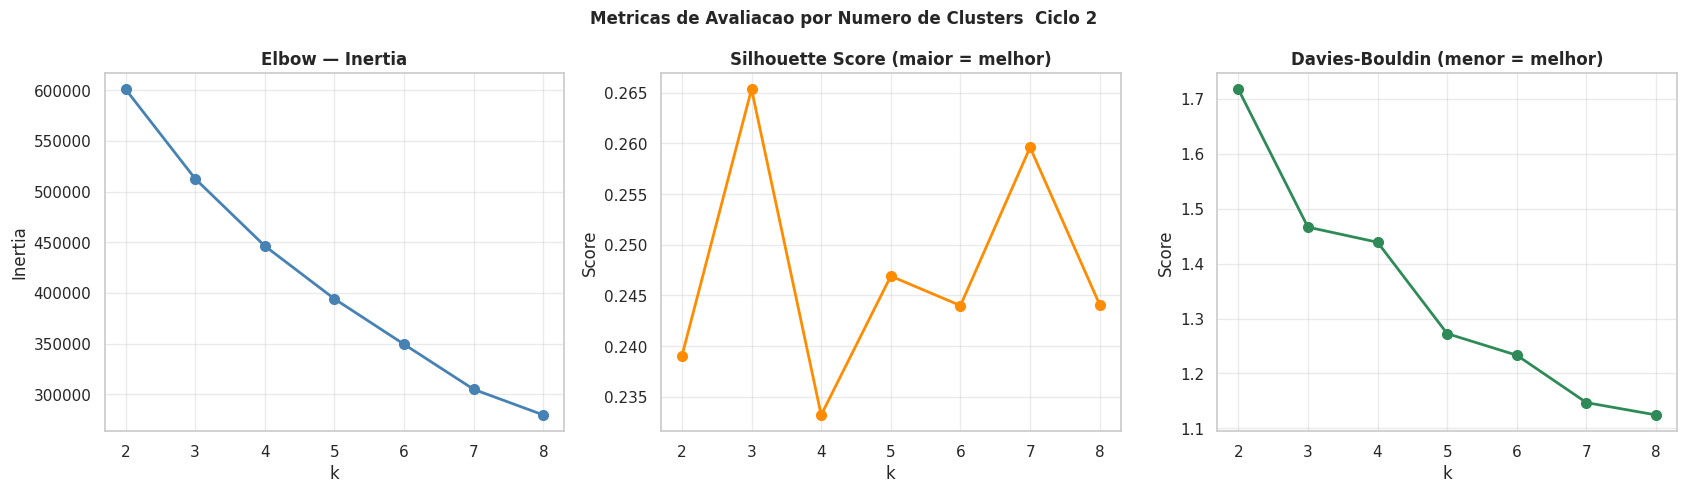

Silhouette maximo    : k=3 (0.265)
Davies-Bouldin minimo: k=8   (1.124)


In [72]:
k_range_v2  = range(2, 9)
inertias_v2 = []
silhs_v2    = []
db_v2       = []

for k in k_range_v2:
    km = KMeans(n_clusters=k, random_state=42, n_init=15, max_iter=500)
    labels = km.fit_predict(X_fit)
    inertias_v2.append(km.inertia_)

    idx = np.random.choice(len(X_fit), min(10000, len(X_fit)), replace=False)
    silhs_v2.append(silhouette_score(X_fit[idx], labels[idx]))
    db_v2.append(davies_bouldin_score(X_fit[idx], labels[idx]))

    print(f'k={k} | Inertia={km.inertia_:>10,.0f} | Silhouette={silhs_v2[-1]:.3f} | Davies-Bouldin={db_v2[-1]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(list(k_range_v2), inertias_v2, 'o-', color='steelblue', lw=2, ms=7)
axes[0].set_title('Elbow — Inertia', fontsize=12, fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.4)

axes[1].plot(list(k_range_v2), silhs_v2, 'o-', color='darkorange', lw=2, ms=7)
axes[1].set_title('Silhouette Score (maior = melhor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.4)

axes[2].plot(list(k_range_v2), db_v2, 'o-', color='seagreen', lw=2, ms=7)
axes[2].set_title('Davies-Bouldin (menor = melhor)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')
axes[2].grid(True, alpha=0.4)

plt.suptitle('Metricas de Avaliacao por Numero de Clusters  Ciclo 2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_silh = list(k_range_v2)[silhs_v2.index(max(silhs_v2))]
best_db   = list(k_range_v2)[db_v2.index(min(db_v2))]
print(f'Silhouette maximo    : k={best_silh} ({max(silhs_v2):.3f})')
print(f'Davies-Bouldin minimo: k={best_db}   ({min(db_v2):.3f})')

### Escolha de k=3

As metricas apontaram k=3 como ponto de equilíbrio entre compactação e interpretabilidade. O ganho de inercia ao passar de k=3 para k=4 nao se traduz em melhora equivalente nas metricas de separação, e clusters adicionais tendem a ser fragmentos de grupos maiores sem diferença comportamental clara. Do ponto de vista de negócio, três segmentos são suficientes para orientar acoes comerciais distintas sem criar complexidade operacional desnecessaria.


## 3.5 Ajuste Final do Modelo


In [73]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=15, max_iter=500)
df_fit['cluster'] = km_final.fit_predict(X_fit)

# Classificar os outliers com o modelo ja treinado
X_out, _ = aplicar_log_e_escalar(df_outliers, scaler=scaler_v2, fit=False)
df_outliers['cluster'] = km_final.predict(X_out)

df_final = pd.concat([df_fit, df_outliers], ignore_index=True)

print(f'KMeans aplicado com k={K_FINAL}')
print()
print('Distribuicao dos clusters:')
for k, n in df_final['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {k}: {n:>7,} clientes ({n / len(df_final) * 100:.1f}%)')

KMeans aplicado com k=3

Distribuicao dos clusters:
  Cluster 0:  31,399 clientes (37.3%)
  Cluster 1:   5,214 clientes (6.2%)
  Cluster 2:  47,633 clientes (56.5%)


## 3.6 Visualização dos Clusters


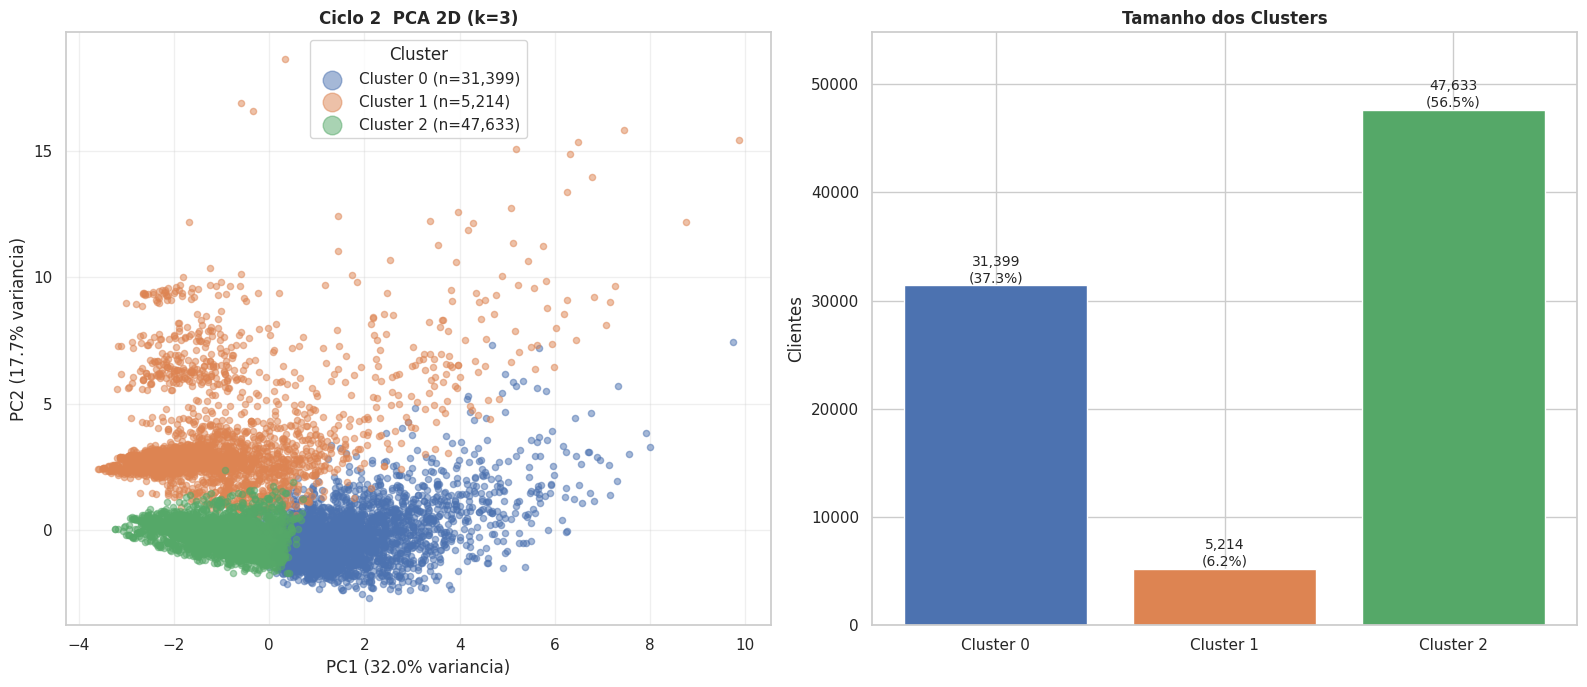

In [74]:
X_all, _ = aplicar_log_e_escalar(df_final, scaler=scaler_v2, fit=False)
pca_v2   = PCA(n_components=2, random_state=42)
X_pca_v2 = pca_v2.fit_transform(X_all)

df_viz       = df_final.copy()
df_viz['pc1'] = X_pca_v2[:, 0]
df_viz['pc2'] = X_pca_v2[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for k in sorted(df_final['cluster'].unique()):
    mask   = df_viz['cluster'] == k
    n      = mask.sum()
    sample = df_viz[mask].sample(min(n, 3000), random_state=42)
    axes[0].scatter(sample['pc1'], sample['pc2'],
                    label=f'Cluster {k} (n={n:,})',
                    alpha=0.5, s=20, color=CORES[k % len(CORES)])

axes[0].set_title(f'Ciclo 2  PCA 2D (k={K_FINAL})', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_v2.explained_variance_ratio_[0]*100:.1f}% variancia)')
axes[0].set_ylabel(f'PC2 ({pca_v2.explained_variance_ratio_[1]*100:.1f}% variancia)')
axes[0].legend(title='Cluster', markerscale=3)
axes[0].grid(True, alpha=0.3)

dist_plot = df_final['cluster'].value_counts().sort_index()
bars = axes[1].bar(
    [f'Cluster {k}' for k in dist_plot.index],
    dist_plot.values,
    color=[CORES[k % len(CORES)] for k in dist_plot.index],
    edgecolor='white'
)
for bar, v in zip(bars, dist_plot.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'{v:,}\n({v / len(df_final) * 100:.1f}%)',
                 ha='center', fontsize=10)
axes[1].set_title('Tamanho dos Clusters', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Clientes')
axes[1].set_ylim(0, dist_plot.max() * 1.15)

plt.tight_layout()
plt.show()

## 3.7 Perfil de Cada Cluster


In [75]:
print('Perfil mediano por cluster:')
display(df_final.groupby('cluster')[FEATURES].median().round(2))

print()
print('Perfil medio por cluster:')
display(df_final.groupby('cluster')[FEATURES].mean().round(2))

Perfil mediano por cluster:


,total_viagens,total_peso,ctes_por_viagem,peso_por_cte,volumes_por_cte,tipo_M_pct,dias_desde_ultimo,freq_diaria,media_perc_desc
cluster,,,,,,,,,
0,9.0,404.30,1.0,42.50,2.57,0.0,3.0,1.25,0.0
1,3.0,1.96,1.0,0.72,3.00,100.0,6.0,1.64,0.0
2,2.0,20.88,1.0,7.00,1.00,0.0,9.0,2.00,0.0



Perfil medio por cluster:


,total_viagens,total_peso,ctes_por_viagem,peso_por_cte,volumes_por_cte,tipo_M_pct,dias_desde_ultimo,freq_diaria,media_perc_desc
cluster,,,,,,,,,
0,25.98,2359.60,1.20,94.88,5.16,6.06,4.48,1.97,0.12
1,8.67,211.94,1.09,3.59,6.57,91.00,8.08,1.73,2.71
2,3.31,37.57,1.04,13.57,1.40,1.17,9.21,1.53,0.00


## 3.8 Enriquecimento Demográfico por Cluster


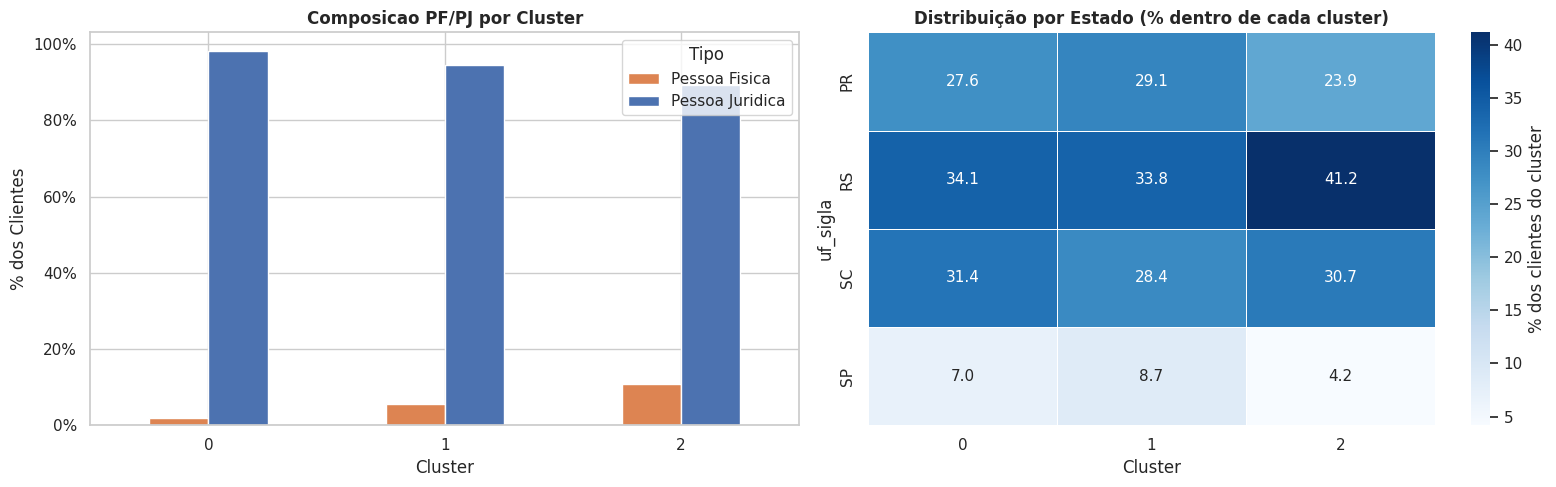

In [76]:
df_info = df.drop_duplicates('cli_codigo')[['cli_codigo', 'cli_fisjur', 'uf_sigla', 'cnae_descr']]
df_rich = df_final.merge(df_info, on='cli_codigo', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cross_tipo = pd.crosstab(df_rich['cluster'], df_rich['cli_fisjur'], normalize='index') * 100
cross_tipo.columns = ['Pessoa Fisica', 'Pessoa Juridica']
cross_tipo.plot(kind='bar', ax=axes[0], color=['#DD8452', '#4C72B0'], edgecolor='white')
axes[0].set_title('Composicao PF/PJ por Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% dos Clientes')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Tipo')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

top_ufs    = df_rich['uf_sigla'].value_counts().head(4).index
cross_uf   = pd.crosstab(
    df_rich[df_rich['uf_sigla'].isin(top_ufs)]['uf_sigla'],
    df_rich[df_rich['uf_sigla'].isin(top_ufs)]['cluster'],
    normalize='columns'
) * 100
sns.heatmap(cross_uf, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '% dos clientes do cluster'})
axes[1].set_title('Distribuição por Estado (% dentro de cada cluster)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

In [77]:
for k in sorted(df_rich['cluster'].unique()):
    subset = df_rich[(df_rich['cluster'] == k) & df_rich['cnae_descr'].notna()]
    top    = subset['cnae_descr'].value_counts().head(5)
    print(f'Cluster {k}  Top 5 CNAEs:')
    for cnae, cnt in top.items():
        pct = cnt / len(df_rich[df_rich['cluster'] == k]) * 100
        print(f'  {pct:5.1f}%  {cnae[:75]}')
    print()

Cluster 0  Top 5 CNAEs:
    5.5%  Comércio a varejo de peças e acessórios novos para veículos automotores
    3.1%  Confecção de peças do vestuário, exceto roupas íntimas e as confeccionadas 
    2.8%  Comércio varejista de outros produtos não especificados anteriormente
    2.6%  Comércio por atacado de peças e acessórios novos para veículos automotores
    2.4%  Comércio atacadista de máquinas, aparelhos e equipamentos para uso agropecu

Cluster 1  Top 5 CNAEs:
    4.6%  Comércio a varejo de peças e acessórios novos para veículos automotores
    3.3%  Comércio varejista de móveis
    2.8%  Confecção de peças do vestuário, exceto roupas íntimas e as confeccionadas 
    2.1%  Comércio varejista de artigos do vestuário e acessórios
    1.9%  Comércio varejista de outros produtos não especificados anteriormente

Cluster 2  Top 5 CNAEs:
    6.2%  Comércio a varejo de peças e acessórios novos para veículos automotores
    3.8%  Serviços de manutenção e reparação mecânica de veículos automo

## 3.9 Interpretacao dos Clusters

Com base nas medianas de cada feature e no enriquecimento demografico, os tres clusters podem ser interpretados da seguinte forma:

| Cluster | Nome | % da Base | Perfil |
|---------|------|-----------|--------|
| 0 | **Clientes Regulares de Medio Porte** | ~37% | Frequencia e peso intermediarios, CTes por viagem moderados, recencia baixa. Presenca consistente ao longo do periodo. |
| 1 | **Clientes Estrategicos de Alto Volume** | ~6% | Alta frequencia diaria, peso total elevado, muitos CTes por viagem. Representam o nucleo da receita da transportadora. |
| 2 | **Clientes Esporadicos de Baixo Volume** | ~57% | Poucas viagens, baixo peso por CTe, recencia alta (enviaram no inicio do periodo e nao retornaram). Maior parcela da base em numero. |





---
## 4. Conclusoes e Proximos Passos

### Achados principais

A base de clientes nos quatro estados de maior densidade operacional (SC, PR, RS, SP) apresenta tres perfis operacionais distintos, com diferencas claras em frequencia de uso, volume por envio e recencia. A concentração observada na EDA se confirma na segmentação: o grupo estrategico, apesar de pequeno em numero, e o que sustenta o volume da operacao.

A transformação logaritmica foi determinante para a qualidade da segmentação. Sem ela, o primeiro ciclo produziu clusters com distribuição extremamente desbalanceada, 97% da base em um unico grupo  porque os totais absolutos sao dominados por poucos clientes de grande porte.

### Proximos passos sugeridos

1. **Incorporar valor do frete** com essa feature  permitiria segmentar por rentabilidade, nao apenas por volume operacional
2. **Ampliar o periodo de analise** para pelo menos tres meses  com apenas 26 dias, metricas de recencia e regularidade tem resolução limitada
3. **Modelo de propensão ao churn**  clientes do segmento esporadico com recencia alta sao candidatos naturais para analise de risco de perda
4. **Segmentação hierarquica**  dentro do grupo estrategico, uma segunda rodada de clusterização pode revelar subtipos com necessidades operacionais diferentes



## 5. Exportar Resultado


In [36]:
df_export = df_final[['cli_codigo', 'cluster'] + FEATURES].copy()

# Salvar em CSV
df_export.to_csv('./data/clientes_segmentados.csv', index=False)
print(f'Arquivo salvo: clientes_segmentados.csv')
print(f'Total de clientes exportados: {len(df_export):,}')
print()
print('Distribuicao final:')
for k, n in df_export['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {k}: {n:,} clientes ({n / len(df_export) * 100:.1f}%)')

# Descomente para subir no banco
df_export.to_sql('clientes_segmentados', engine, if_exists='replace', index=False)
print('Tabela clientes_segmentados criada no banco.')

Arquivo salvo: clientes_segmentados.csv
Total de clientes exportados: 84,246

Distribuicao final:
  Cluster 0: 31,399 clientes (37.3%)
  Cluster 1: 5,214 clientes (6.2%)
  Cluster 2: 47,633 clientes (56.5%)
Tabela clientes_segmentados criada no banco.
